<a href="https://colab.research.google.com/github/jeisteve999/africa-procurement-risk-analysis/blob/main/Africa_Procurement_Risk_Analysis_%E2%80%94_Kenya_%26_Uganda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("/content/contratos_africanos_redflags.csv")

In [3]:
df = pd.read_csv("contratos_africanos_redflags.csv")
df

,tender_id,tender_title,buyer_name,bidder_name,tender_value,tender_currency,tender_status,tender_date,single_bidding,tax_haven,short_bidding_period,direct_adjudication
0,CONT-UGA-2026001,Adquisición de insumos y obras en National Wat...,National Water and Sewerage Corp,Apex Books and Stationery,UGX 156932,UGX,En proceso,07/10/2025,0,0,0,0
1,CONT-KEN-2026002,Adquisición de insumos y obras en Ministry of ...,Ministry of Health,Victoria Water Works Ltd,KES 239176,KES,Cancelado,25/01/2025,0,0,0,0
2,CONT-UGA-2026003,Adquisición de insumos y obras en Ministry of ...,Ministry of Health Uganda,Kiprono & Sons Enterprises,"UGX 298,538.00",UGX,En proceso,2024-07-09,1,0,0,1
3,CONT-KEN-2026004,Adquisición de insumos y obras en Ministry of ...,Ministry of Water & Irrigation,Shelter Dev Offshore Co,"597,843.00 reales",KES,Adjudicado,04/02/2024,0,1,0,1
4,CONT-UGA-2026005,Adquisición de insumos y obras en Ministry of ...,Ministry of Health Uganda,Horizon Logistics Ltd,"589,685.00 reales",UGX,En proceso,2025-02-16,0,0,0,0
5,CONT-KEN-2026006,Adquisición de insumos y obras en Ministry of ...,Ministry of Education,Horizon Logistics Ltd,"480,808.00 reales",KES,Adjudicado,19/01/2025,1,0,1,1
6,CONT-UGA-2026007,Adquisición de insumos y obras en Ministry of ...,Ministry of Works and Transport,Shelter Dev Offshore Co,UGX 846654,UGX,Cancelado,08/06/2025,1,1,1,1
7,CONT-KEN-2026008,Adquisición de insumos y obras en National Roa...,National Road Authority,Kiprono & Sons Enterprises,"243,126.00 reales",KES,Adjudicado,07/01/2023,0,0,0,0
8,CONT-UGA-2026009,Adquisición de insumos y obras en Ministry of ...,Ministry of Education and Sports,Sino-East Africa Roads Corp,UGX 396369,UGX,Cancelado,2024-12-28,0,0,0,1
9,CONT-KEN-2026010,Adquisición de insumos y obras en Ministry of ...,Ministry of Education,Apex Books and Stationery,"KES 152,948.00",KES,Adjudicado,09/05/2023,1,0,0,1


In [4]:
df["tender_date"] = pd.to_datetime(df["tender_date"], format="mixed", dayfirst= True, errors="coerce")
print(df["tender_date"].dtype)
print(df["tender_date"].isnull().sum(), "Fechas que quedaron sin convertirse")

datetime64[ns]
3 Fechas que quedaron sin convertirse


In [5]:
df.shape

(60, 12)

In [6]:
df.dtypes

,0
tender_id,object
tender_title,object
buyer_name,object
bidder_name,object
tender_value,object
tender_currency,object
tender_status,object
tender_date,datetime64[ns]
single_bidding,int64
tax_haven,int64


In [7]:
df.isnull().sum()

,0
tender_id,0
tender_title,0
buyer_name,1
bidder_name,0
tender_value,0
tender_currency,0
tender_status,0
tender_date,3
single_bidding,0
tax_haven,0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
import re

def limpiar_precio(valor):
    texto = str(valor)
    texto = re.sub(r"[^\d.]", "", texto)
    return float(texto)

df["tender_value"] = df["tender_value"].apply(limpiar_precio)

In [10]:
## Quitar espacios sueltos en columnas de texto

columnas_texto = ["tender_title", "buyer_name", "bidder_name"]
for col in columnas_texto:
  df[col] = df[col].str.strip()

#Convertir columnas repetitivas a category

df["tender_status"]= df["tender_status"].astype("category")
df["tender_currency"] = df["tender_currency"].astype("category")


In [11]:
df.isnull().sum()


,0
tender_id,0
tender_title,0
buyer_name,1
bidder_name,0
tender_value,0
tender_currency,0
tender_status,0
tender_date,3
single_bidding,0
tax_haven,0


In [12]:
df.dtypes

,0
tender_id,object
tender_title,object
buyer_name,object
bidder_name,object
tender_value,float64
tender_currency,category
tender_status,category
tender_date,datetime64[ns]
single_bidding,int64
tax_haven,int64


In [13]:
df.head()

,tender_id,tender_title,buyer_name,bidder_name,tender_value,tender_currency,tender_status,tender_date,single_bidding,tax_haven,short_bidding_period,direct_adjudication
0,CONT-UGA-2026001,Adquisición de insumos y obras en National Wat...,National Water and Sewerage Corp,Apex Books and Stationery,156932.0,UGX,En proceso,2025-10-07,0,0,0,0
1,CONT-KEN-2026002,Adquisición de insumos y obras en Ministry of ...,Ministry of Health,Victoria Water Works Ltd,239176.0,KES,Cancelado,2025-01-25,0,0,0,0
2,CONT-UGA-2026003,Adquisición de insumos y obras en Ministry of ...,Ministry of Health Uganda,Kiprono & Sons Enterprises,298538.0,UGX,En proceso,2024-07-09,1,0,0,1
3,CONT-KEN-2026004,Adquisición de insumos y obras en Ministry of ...,Ministry of Water & Irrigation,Shelter Dev Offshore Co,597843.0,KES,Adjudicado,2024-02-04,0,1,0,1
4,CONT-UGA-2026005,Adquisición de insumos y obras en Ministry of ...,Ministry of Health Uganda,Horizon Logistics Ltd,589685.0,UGX,En proceso,2025-02-16,0,0,0,0


In [14]:
df.sort_values("tender_value", ascending= False)

,tender_id,tender_title,buyer_name,bidder_name,tender_value,tender_currency,tender_status,tender_date,single_bidding,tax_haven,short_bidding_period,direct_adjudication
6,CONT-UGA-2026007,Adquisición de insumos y obras en Ministry of ...,Ministry of Works and Transport,Shelter Dev Offshore Co,846654.0,UGX,Cancelado,2025-06-08,1,1,1,1
27,CONT-KEN-2026028,Adquisición de insumos y obras en National Roa...,National Road Authority,,831790.0,KES,En proceso,2023-08-11,0,0,0,1
22,CONT-UGA-2026023,Adquisición de insumos y obras en Ministry of ...,Ministry of Health Uganda,Sino-East Africa Roads Corp,828451.0,UGX,Adjudicado,2025-10-28,0,0,0,0
51,CONT-KEN-2026052,Adquisición de insumos y obras en Ministry of ...,Ministry of Education,Kiprono & Sons Enterprises,797042.0,KES,Adjudicado,2024-05-17,1,1,0,1
15,CONT-KEN-2026016,Adquisición de insumos y obras en National Roa...,National Road Authority,Kiprono & Sons Enterprises,792836.0,KES,Adjudicado,2023-03-22,0,0,0,0
30,CONT-UGA-2026031,Adquisición de insumos y obras en Ministry of ...,Ministry of Health Uganda,Victoria Water Works Ltd,786315.0,UGX,Adjudicado,2024-05-07,1,0,0,1
19,CONT-KEN-2026020,Adquisición de insumos y obras en National Roa...,National Road Authority,Mukasa Engineering,780073.0,KES,Adjudicado,2025-06-11,1,0,1,1
17,CONT-KEN-2026018,Adquisición de insumos y obras en Ministry of ...,Ministry of Education,,736851.0,KES,En proceso,NaT,1,0,1,1
38,CONT-UGA-2026039,Adquisición de insumos y obras en Ministry of ...,Ministry of Works and Transport,Victoria Water Works Ltd,728286.0,UGX,Adjudicado,2024-05-05,0,0,0,0
32,CONT-UGA-2026033,Adquisición de insumos y obras en Ministry of ...,Ministry of Health Uganda,Alpha Construction Ltd,717440.0,UGX,Cancelado,2024-12-19,0,0,0,0


In [15]:
df = df.dropna(subset=['buyer_name', 'tender_date'])

In [16]:
df.to_csv("contratos_redflags_clean.csv", index=False)

In [17]:
df.describe()

,tender_value,tender_date,single_bidding,tax_haven,short_bidding_period,direct_adjudication
count,56.00000,56,56.000000,56.000000,56.000000,56.000000
mean,386554.75000,2024-06-11 06:25:42.857142784,0.285714,0.178571,0.160714,0.517857
min,26917.00000,2023-01-05 00:00:00,0.000000,0.000000,0.000000,0.000000
25%,182562.75000,2023-05-16 06:00:00,0.000000,0.000000,0.000000,0.000000
50%,335309.50000,2024-06-09 12:00:00,0.000000,0.000000,0.000000,1.000000
75%,591724.50000,2025-03-03 06:00:00,1.000000,0.000000,0.000000,1.000000
max,846654.00000,2025-12-17 00:00:00,1.000000,1.000000,1.000000,1.000000
std,249700.81715,NaN,0.455842,0.386459,0.370591,0.504203


In [18]:
por_comprador = df.sort_values(by='buyer_name', ascending=False)
por_valor = df.sort_values(by='tender_value', ascending=False)

In [19]:
contratos_ordenados = df.sort_values(by='tender_value', ascending= False)

In [20]:
print("---Los 5 Contratos mas caros encontrados")

---Los 5 Contratos mas caros encontrados


In [21]:
print(por_comprador .head(5))
print(por_valor .head(5))

           tender_id                                       tender_title  \
0   CONT-UGA-2026001  Adquisición de insumos y obras en National Wat...   
56  CONT-UGA-2026057  Adquisición de insumos y obras en National Wat...   
18  CONT-UGA-2026019  Adquisición de insumos y obras en National Wat...   
48  CONT-UGA-2026049  Adquisición de insumos y obras en National Wat...   
46  CONT-UGA-2026047  Adquisición de insumos y obras en National Wat...   

                          buyer_name                 bidder_name  \
0   National Water and Sewerage Corp   Apex Books and Stationery   
56  National Water and Sewerage Corp      Global Pharma Supplies   
18  National Water and Sewerage Corp    Victoria Water Works Ltd   
48  National Water and Sewerage Corp       Horizon Logistics Ltd   
46  National Water and Sewerage Corp  Kiprono & Sons Enterprises   

    tender_value tender_currency tender_status tender_date  single_bidding  \
0       156932.0             UGX    En proceso  2025-10-07    

In [22]:
df.dtypes

,0
tender_id,object
tender_title,object
buyer_name,object
bidder_name,object
tender_value,float64
tender_currency,category
tender_status,category
tender_date,datetime64[ns]
single_bidding,int64
tax_haven,int64


In [23]:
df["tender_status"].value_counts()

,count
tender_status,
Adjudicado,30
En proceso,16
Cancelado,10


In [24]:
# ¿Qué monedas aparecen y cuál es la más frecuente?

df["tender_currency"].value_counts()

,count
tender_currency,
KES,28
UGX,28


In [25]:
df["buyer_name"].value_counts()

,count
buyer_name,
Ministry of Education,11
Ministry of Education and Sports,9
Ministry of Health Uganda,8
National Water and Sewerage Corp,7
Ministry of Water & Irrigation,6
National Road Authority,5
Ministry of Health,4
Ministry of Works and Transport,4
Ministry of Energy,2


In [26]:
# ¿Qué compradores tienen más contratos?

df["tender_value"].describe()

,tender_value
count,56.00000
mean,386554.75000
std,249700.81715
min,26917.00000
25%,182562.75000
50%,335309.50000
75%,591724.50000
max,846654.00000


In [27]:
# ¿Cuáles compradores concentran mayor valor contratado?

df.groupby("buyer_name")["tender_value"].sum().sort_values(ascending=False)

,tender_value
buyer_name,
Ministry of Education,3681694.0
Ministry of Health Uganda,3662578.0
National Road Authority,3333307.0
Ministry of Education and Sports,2832310.0
Ministry of Works and Transport,2256756.0
National Water and Sewerage Corp,2062521.0
Ministry of Water & Irrigation,1636735.0
Ministry of Health,1300800.0
Ministry of Energy,880365.0


In [28]:
# ¿Cuáles compradores tienen contratos de mayor valor promedio?

df.groupby("buyer_name")["tender_value"].mean().sort_values(ascending=False).head()

,tender_value
buyer_name,
National Road Authority,666661.400000
Ministry of Works and Transport,564189.000000
Ministry of Health Uganda,457822.250000
Ministry of Energy,440182.500000
Ministry of Education,334699.454545


In [29]:
# ¿Cuánto dinero hay asociado a cada estado de contrato?

df.groupby("tender_status")["tender_value"].sum()

/tmp/ipykernel_1626/664486742.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("tender_status")["tender_value"].sum()


,tender_value
tender_status,
Adjudicado,12436004.0
Cancelado,4207557.0
En proceso,5003505.0


In [30]:
df["buyer_name"].value_counts()

,count
buyer_name,
Ministry of Education,11
Ministry of Education and Sports,9
Ministry of Health Uganda,8
National Water and Sewerage Corp,7
Ministry of Water & Irrigation,6
National Road Authority,5
Ministry of Health,4
Ministry of Works and Transport,4
Ministry of Energy,2


In [31]:
df["buyer_name"].value_counts().head(10)

,count
buyer_name,
Ministry of Education,11
Ministry of Education and Sports,9
Ministry of Health Uganda,8
National Water and Sewerage Corp,7
Ministry of Water & Irrigation,6
National Road Authority,5
Ministry of Health,4
Ministry of Works and Transport,4
Ministry of Energy,2


In [32]:
df.groupby("buyer_name")["tender_value"].sum().sort_values(ascending=False).head(10)

,tender_value
buyer_name,
Ministry of Education,3681694.0
Ministry of Health Uganda,3662578.0
National Road Authority,3333307.0
Ministry of Education and Sports,2832310.0
Ministry of Works and Transport,2256756.0
National Water and Sewerage Corp,2062521.0
Ministry of Water & Irrigation,1636735.0
Ministry of Health,1300800.0
Ministry of Energy,880365.0


In [33]:
df["tender_status"].value_counts()

,count
tender_status,
Adjudicado,30
En proceso,16
Cancelado,10


In [34]:
df.groupby("tender_status")["tender_value"].sum()

/tmp/ipykernel_1626/1754930312.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("tender_status")["tender_value"].sum()


,tender_value
tender_status,
Adjudicado,12436004.0
Cancelado,4207557.0
En proceso,5003505.0


In [35]:
# ¿Qué estado tiene el mayor valor total de contratos?

df.groupby("tender_status")["tender_value"].sum().sort_values(ascending=False)

/tmp/ipykernel_1626/3770055519.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("tender_status")["tender_value"].sum().sort_values(ascending=False)


,tender_value
tender_status,
Adjudicado,12436004.0
En proceso,5003505.0
Cancelado,4207557.0


In [36]:
# ¿Cuál es el valor promedio de un contrato en cada tender_status?
df.groupby("tender_status")["tender_value"].mean().sort_values(ascending=False)

/tmp/ipykernel_1626/758917580.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("tender_status")["tender_value"].mean().sort_values(ascending=False)


,tender_value
tender_status,
Cancelado,420755.700000
Adjudicado,414533.466667
En proceso,312719.062500


In [37]:
# ¿Cuántos contratos tenemos por año?

df["tender_date"].dt.year.value_counts()

,count
tender_date,
2025,21
2023,19
2024,16


In [38]:
# ¿Cuál fue el valor total de los contratos en cada año?
df.groupby(df["tender_date"].dt.year)["tender_value"].sum()

,tender_value
tender_date,
2023,6896941.0
2024,6692600.0
2025,8057525.0


In [39]:
# ¿Cuánto dinero en contratos se registró en cada año?

df["year"] = df["tender_date"].dt.year

df.groupby("year")["tender_value"].sum()

/tmp/ipykernel_1626/166571993.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["year"] = df["tender_date"].dt.year


,tender_value
year,
2023,6896941.0
2024,6692600.0
2025,8057525.0


In [40]:
# ¿Cuál fue el año con MAYOR valor total de contratos?

df.groupby("year")["tender_value"].sum().sort_values(ascending=False)

,tender_value
year,
2025,8057525.0
2023,6896941.0
2024,6692600.0


In [41]:
df.columns

Index(['tender_id', 'tender_title', 'buyer_name', 'bidder_name',
       'tender_value', 'tender_currency', 'tender_status', 'tender_date',
       'single_bidding', 'tax_haven', 'short_bidding_period',
       'direct_adjudication', 'year'],
      dtype='object')

In [42]:
df["tender_currency"].value_counts()

,count
tender_currency,
KES,28
UGX,28


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 56 entries, 0 to 59
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   tender_id             56 non-null     object        
 1   tender_title          56 non-null     object        
 2   buyer_name            56 non-null     object        
 3   bidder_name           56 non-null     object        
 4   tender_value          56 non-null     float64       
 5   tender_currency       56 non-null     category      
 6   tender_status         56 non-null     category      
 7   tender_date           56 non-null     datetime64[ns]
 8   single_bidding        56 non-null     int64         
 9   tax_haven             56 non-null     int64         
 10  short_bidding_period  56 non-null     int64         
 11  direct_adjudication   56 non-null     int64         
 12  year                  56 non-null     int32         
dtypes: category(2), datetime64[

In [44]:
df["year"].dtype

dtype('int32')

In [45]:
df["tender_status"].value_counts()

,count
tender_status,
Adjudicado,30
En proceso,16
Cancelado,10


In [46]:
df["tender_currency"].value_counts()

,count
tender_currency,
KES,28
UGX,28


In [47]:
df["single_bidding"].value_counts()

,count
single_bidding,
0,40
1,16


In [48]:
df["tender_value"].value_counts()

,count
tender_value,
156932.0,1
239176.0,1
298538.0,1
597843.0,1
589685.0,1
480808.0,1
846654.0,1
243126.0,1
396369.0,1


In [49]:
df["tender_currency"].value_counts()

,count
tender_currency,
KES,28
UGX,28


In [50]:
df["tender_value"].describe()

,tender_value
count,56.00000
mean,386554.75000
std,249700.81715
min,26917.00000
25%,182562.75000
50%,335309.50000
75%,591724.50000
max,846654.00000


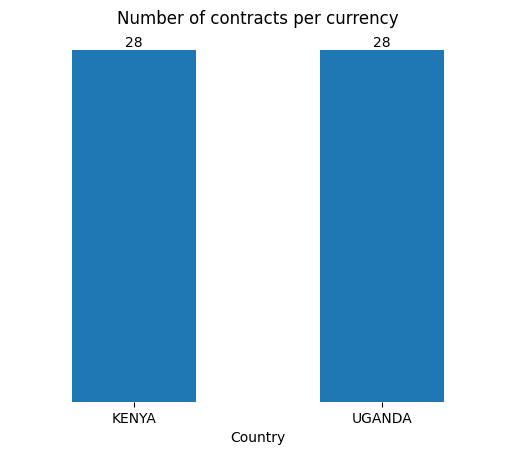

In [51]:
import matplotlib.pyplot as plt

counts = df["tender_currency"].value_counts()

counts.index = counts.index.map({
    "KES": "KENYA",
    "UGX": "UGANDA"
})

ax = counts.plot(kind="bar")
plt.title("Number of contracts per currency")
plt.xlabel("Country")

ax.get_yaxis().set_visible(False)
plt.box(False)

for i, value in enumerate(counts):
  ax.text(i, value, str(value), ha="center", va="bottom")

plt.xticks(rotation= False)

plt.show()

In [52]:
df["direct_adjudication"].value_counts()

,count
direct_adjudication,
1,29
0,27


In [53]:
pd.crosstab(df["tender_currency"], df["direct_adjudication"])

direct_adjudication,0,1
tender_currency,,
KES,11,17
UGX,16,12


# Uganda has a higher proportion of contracts awarded through direct adjudication than Kenya.

/tmp/ipykernel_1626/2307616151.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["country"] = df["tender_currency"].map({
/tmp/ipykernel_1626/2307616151.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("country")["direct_adjudication"]


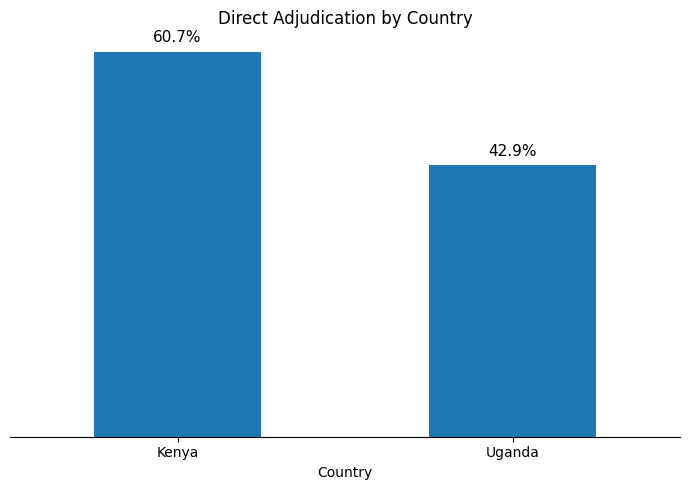

In [54]:
import pandas as pd
import matplotlib.pyplot as plt

df["country"] = df["tender_currency"].map({
    "KES": "Kenya",
    "UGX": "Uganda"
})

direct_adjudication_pct = (
    df.groupby("country")["direct_adjudication"]
    .mean()
    .mul(100)
)

fig, ax = plt.subplots(figsize=(7, 5))

direct_adjudication_pct.plot(
    kind="bar",
    ax=ax
)

plt.title("Direct Adjudication by Country")
plt.xlabel("Country")

# Remove Y-axis
ax.get_yaxis().set_visible(False)

# Remove chart frame
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

# Add percentage labels
for i, value in enumerate(direct_adjudication_pct):
    ax.text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Kenya has a higher proportion of direct adjudication contracts (60.7%) compared with Uganda (42.9%).

In [55]:
# How competitive are the procurement processes?

pd.crosstab(
    df["tender_currency"],
    df["single_bidding"]
)

single_bidding,0,1
tender_currency,,
KES,19,9
UGX,21,7


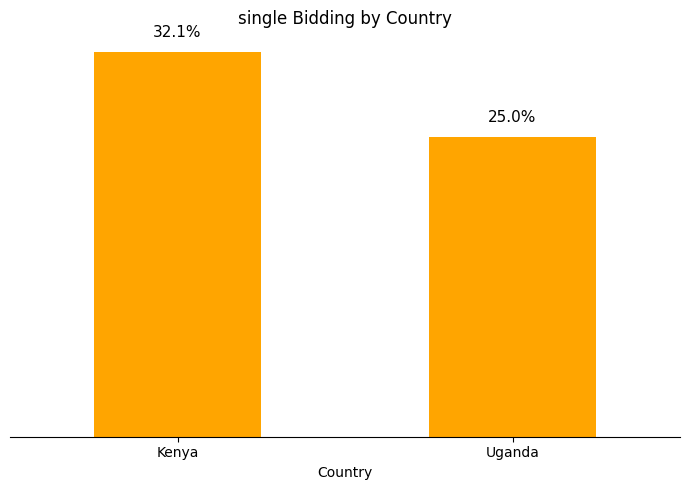

In [56]:
import pandas as pd
import matplotlib.pyplot as plt

single_bidding_pct = (
    df.groupby("country", observed=False)["single_bidding"]
    .mean()
    .mul(100)
)

fig, ax = plt.subplots(figsize=(7, 5))
single_bidding_pct.plot(
    kind="bar",
    ax=ax,
    color="orange"
)

plt.title("single Bidding by Country")
plt.xlabel("Country")

ax.get_yaxis().set_visible(False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

for i, value in enumerate(single_bidding_pct):
    ax.text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize = 11
    )

plt.xticks(rotation= 0)
plt.tight_layout()
plt.show()

# Kenya represents 32.1% of contracts with single bidding, while Uganda represents 25.0%. Kenya has 7.1 percentage points higher

In [57]:
# Short Bidding Period by Country

pd.crosstab(df["country"],
            df["short_bidding_period"]
            )

short_bidding_period,0,1
country,,
Kenya,24,4
Uganda,23,5


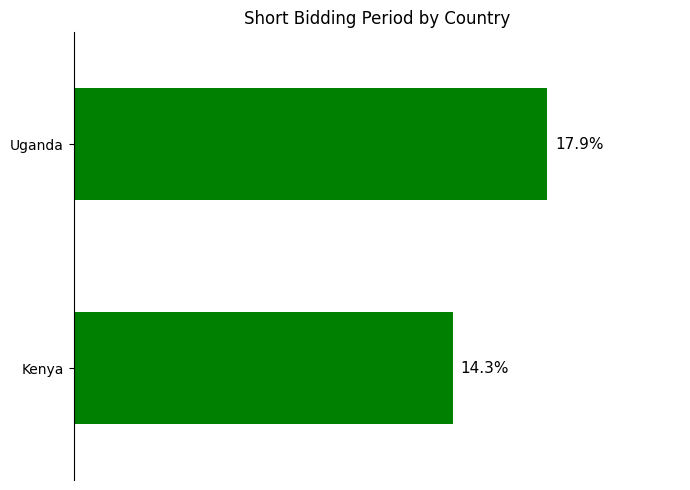

In [58]:
import matplotlib.pyplot as plt

plt.close('all')

short_bidding_pct = (
    df.groupby("country", observed=False)["short_bidding_period"]
      .mean()
      .mul(100)
      .sort_values()
)

fig, ax = plt.subplots(figsize=(7, 5))

short_bidding_pct.plot(
    kind="barh",
    ax=ax,
    color="green"
)

ax.set_title("Short Bidding Period by Country")
ax.set_xlabel("")
ax.set_ylabel("")

ax.set_xticks([])
ax.spines["bottom"].set_visible(False)



for i, value in enumerate(short_bidding_pct):
    ax.text(
        value + 0.3,
        i,
        f"{value:.1f}%",
        va="center",
        fontsize=11
    )

ax.set_xlim(0, short_bidding_pct.max() + 5)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# Uganda has a higher proportion of tenders with short bidding periods (17.9%) compared with Kenya (14.3%), indicating that short bidding windows are somewhat more common in Uganda.

In [59]:
pd.crosstab(
    df["country"], df["tax_haven"]
)

tax_haven,0,1
country,,
Kenya,22,6
Uganda,24,4


/tmp/ipykernel_1626/3439332478.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("country")["tax_haven"]


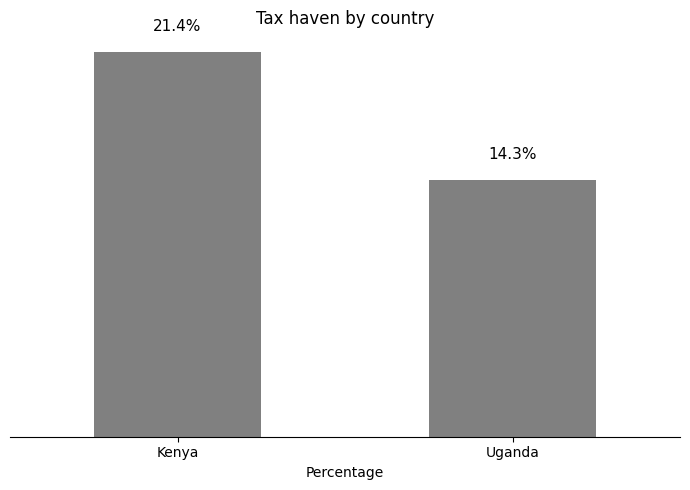

In [62]:
tax_haven_pct = (
    df.groupby("country")["tax_haven"]
    .mean()
    .mul(100)
)

fig, ax = plt.subplots(figsize=(7, 5))

tax_haven_pct.plot(
    kind= "bar",
    ax=ax,
    color = "grey"
)

plt.title("Tax haven by country")
plt.xlabel("Percentage")
plt.ylabel("Country")


ax.get_yaxis().set_visible(False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

for i, value in enumerate(tax_haven_pct):
    ax.text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=11
    )
plt.xticks(rotation= 0)
plt.tight_layout()
plt.show()

# Kenya shows a tax-haven indicator in 21.4% of contracts, suggesting that a relevant share of procurement transactions involves entities or jurisdictions flagged under this indicator.

In [71]:
# Combined Procurement Risk Indicators

df = df.copy()
risk_columns = [
    "single_bidding",
    "short_bidding_period",
    "direct_adjudication",
    "tax_haven",
]

df["risk_score"]= df[risk_columns].sum(axis=1)

In [72]:
df["risk_score"].value_counts().sort_index()

,count
risk_score,
0,21
1,13
2,17
3,3
4,2


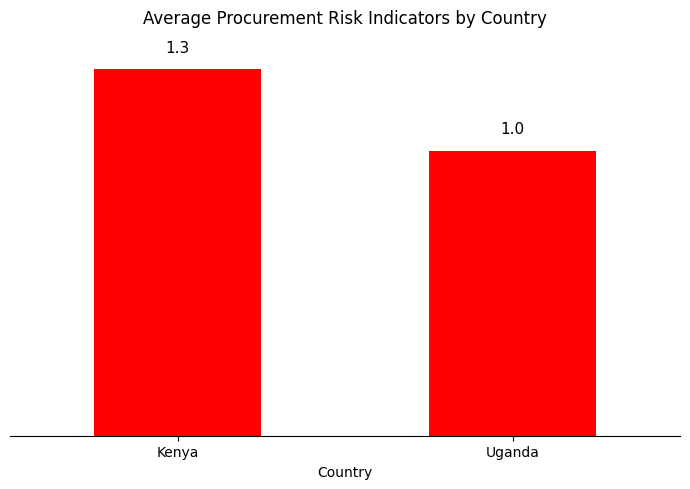

In [77]:
# Promedio de indicadores por pais

risk_by_country = (
    df.groupby("country", observed= False)["risk_score"]
    .mean()
)

fig, ax = plt.subplots(figsize =(7, 5))

risk_by_country.plot(
    kind="bar",
    ax = ax,
    color="red"
)

plt.title("Average Procurement Risk Indicators by Country", pad= 20)
plt.xlabel("Country")

ax.get_yaxis().set_visible(False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

for i, value in enumerate(risk_by_country):
    ax.text(
        i,
        value + 0.05,
        f"{value:.1f}",
        ha="center",
        va="bottom",
        fontsize= 11
    )

plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

# Kenya shows a higher average number of procurement risk indicators per contract (1.3) compared with Uganda (1.0), suggesting that Kenyan contracts in the dataset exhibit a greater concentration of the selected risk indicators.

In [78]:
# Procurement Activity Over Time

contracts_by_year = (
    df.groupby(["year", "country"], observed=False)
    .size()
    .unstack(fill_value=0)
)

contracts_by_year

country,Kenya,Uganda
year,,
2023,12,7
2024,6,10
2025,10,11


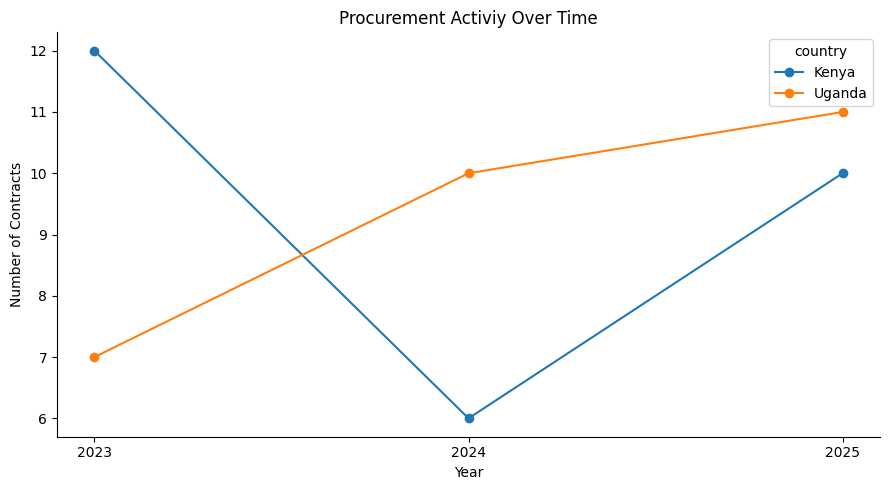

In [85]:
fig, ax = plt.subplots(figsize = (9, 5))

contracts_by_year.plot(
    kind="line",
    marker="o",
    ax = ax
)

plt.title("Procurement Activiy Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Contracts")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xticks(contracts_by_year.index)
plt.tight_layout()
plt.show()

# Procurement activity shifted from Kenya to Uganda over the period analyzed. Kenya led in 2023, but Uganda surpassed Kenya in both 2024 and 2025, while Kenya's procurement activity fluctuated more substantially.